# Intro to Data Science - Solution to Homework 1 - Wilmington College


## Q1: Climate and Environmental Data Analysis 
 
As a data scientist working in environmental research, you are analyzing climate patterns and temperature fluctuations in different regions. Your goal is to process and analyze temperature data using **NumPy operations efficiently**. 

### **1. Advanced Array Operations:**  
You have temperature readings (in Celsius) for five consecutive days from three different cities:  
```python
city1 = np.array([12, 15, 18, 20, 22])  
city2 = np.array([10, 14, 19, 23, 28])  
city3 = np.array([5, 10, 15, 20, 25])  
```
- a. **Stack** these arrays into a **2D NumPy array** where each row represents a city, and each column represents a day.  
- b. Compute the **row-wise mean** temperature for each city.  
- c. Compute the **column-wise maximum** temperature recorded on each day.  
- d. Convert all temperatures from **Celsius to Fahrenheit** using broadcasting:  
   $$
   F = C \times \frac{9}{5} + 32
   $$
- e. Identify the **index positions** where temperatures exceeded **20°C**.

In [4]:
#     **Solution**
# Type your solution here.

import numpy as np

city1 = np.array([12, 15, 18, 20, 22])
city2 = np.array([10, 14, 19, 23, 28])
city3 = np.array([5, 10, 15, 20, 25])

# a. Stack these arrays into a 2D NumPy array
temps = np.vstack([city1, city2, city3])
print("2D Temperature Array:\n", temps, "\n")

# b. Compute the row-wise mean temperature for each city
row_mean = np.mean(temps, axis=1)
print("Row-wise mean temperatures:", row_mean, "\n")

# c. Compute the column-wise maximum temperature recorded on each day
col_max = np.max(temps, axis=0)
print("Column-wise max temperatures:", col_max, "\n")

# d. Convert temperatures from Celsius to Fahrenheit
temps_f = (temps * 9/5) + 32
print("Temperatures in Fahrenheit:\n", temps_f, "\n")

# e. Identify index positions where temperatures exceeded 20°C
indices = np.argwhere(temps > 20)
print("Indices where temperature exceeded 20°C:", indices)


2D Temperature Array:
 [[12 15 18 20 22]
 [10 14 19 23 28]
 [ 5 10 15 20 25]] 

Row-wise mean temperatures: [17.4 18.8 15. ] 

Column-wise max temperatures: [12 15 19 23 28] 

Temperatures in Fahrenheit:
 [[53.6 59.  64.4 68.  71.6]
 [50.  57.2 66.2 73.4 82.4]
 [41.  50.  59.  68.  77. ]] 

Indices where temperature exceeded 20°C: [[0 4]
 [1 3]
 [1 4]
 [2 4]]


### Q2. Conditional Logic & Boolean Indexing:

You are given daily temperature readings for a month in a city:  

```python
monthly_temps = np.random.randint(5, 35, size=30)  # Generates random temperatures between 5 and 35°C  
```  
- a. Create an array `temp_category` where temperatures **≥ 25°C** are labeled as `"Hot"`, temperatures between **15-24°C** as `"Moderate"`, and temperatures **≤ 14°C** as `"Cold"`.  

- b. Count how many days were `"Hot"`, `"Moderate"`, and `"Cold"`.  
- c. Replace all `"Cold"` days (≤ 14°C) with the mean temperature of the `"Moderate"` days.  
- d. Find the **top 3 hottest days** and their corresponding indices in `monthly_temps`.  


In [11]:
#     **Solution**
# Type your solution here.

monthly_temps = np.random.randint(5, 35, size=30)
print("Monthly Temperatures:", monthly_temps, "\n")


# a. Categorize temperatures into "Hot", "Moderate", and "Cold"
temp_category = np.where(monthly_temps >= 25, "Hot",
                         np.where(monthly_temps >= 15, "Moderate", "Cold"))
print("Temperature Categories:", temp_category, "\n")

# b. Count occurrences of each category
unique, counts = np.unique(temp_category, return_counts=True)
category_counts = dict(zip(unique, counts))
print("Category Counts:", category_counts, "\n")

# c. Replace "Cold" days (≤ 14°C) with mean of "Moderate" days
moderate_mask = (monthly_temps >= 15) & (monthly_temps < 25)
moderate_mean = np.mean(monthly_temps[moderate_mask])
monthly_temps[monthly_temps <= 14] = moderate_mean
print("Adjusted Monthly Temperatures:", monthly_temps, "\n")

# d. Find the top 3 hottest days and their indices
top_3_indices = np.argsort(monthly_temps)[-3:]
top_3_temps = monthly_temps[top_3_indices]
print("Top 3 hottest days:", top_3_temps, "at indices:", top_3_indices)


Monthly Temperatures: [ 6  8 22 33 24 34 11 21 17  6 30  7 31 17 32 25 10  9  5 11 28 32 22 25
 25 15  9 20 34 12] 

Temperature Categories: ['Cold' 'Cold' 'Moderate' 'Hot' 'Moderate' 'Hot' 'Cold' 'Moderate'
 'Moderate' 'Cold' 'Hot' 'Cold' 'Hot' 'Moderate' 'Hot' 'Hot' 'Cold' 'Cold'
 'Cold' 'Cold' 'Hot' 'Hot' 'Moderate' 'Hot' 'Hot' 'Moderate' 'Cold'
 'Moderate' 'Hot' 'Cold'] 

Category Counts: {np.str_('Cold'): np.int64(11), np.str_('Hot'): np.int64(11), np.str_('Moderate'): np.int64(8)} 

Adjusted Monthly Temperatures: [19 19 22 33 24 34 19 21 17 19 30 19 31 17 32 25 19 19 19 19 28 32 22 25
 25 15 19 20 34 19] 

Top 3 hottest days: [33 34 34] at indices: [ 3  5 28]


### Q3. Statistical & Mathematical Operations:

Given an array of test scores from an environmental science class:  

```python
scores = np.array([78, 85, 92, 88, 76, 95, 89, 83, 90, 87])  
```  
- a. Compute the **mean, median, standard deviation, and variance** of the scores.  
- b. Determine the **25th and 75th percentile** of the scores.  
- c. Normalize the test scores to be between **0 and 1** using min-max scaling:  
   $$
   X_{\text{norm}} = \frac{X - \min(X)}{\max(X) - \min(X)}
   $$
- d. Apply **boolean indexing** to extract test scores greater than one standard deviation above the mean.  



In [12]:
#     **Solution**
# Type your solution here.


scores = np.array([78, 85, 92, 88, 76, 95, 89, 83, 90, 87])

# a. Mean, Median, Standard Deviation, Variance
mean_score = np.mean(scores)
median_score = np.median(scores)
std_dev = np.std(scores)
variance = np.var(scores)

print("Mean:", mean_score)
print("Median:", median_score)
print("Standard Deviation:", std_dev)
print("Variance:", variance, "\n")

# b. 25th and 75th percentiles
percentile_25 = np.percentile(scores, 25)
percentile_75 = np.percentile(scores, 75)
print("25th Percentile:", percentile_25)
print("75th Percentile:", percentile_75, "\n")

# c. Normalize scores between 0 and 1
scores_normalized = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))
print("Normalized Scores:", scores_normalized, "\n")

# d. Extract scores > 1 standard deviation above mean
high_scores = scores[scores > mean_score + std_dev]
print("Scores > 1 Standard Deviation above Mean:", high_scores)


Mean: 86.3
Median: 87.5
Standard Deviation: 5.657738063926255
Variance: 32.010000000000005 

25th Percentile: 83.5
75th Percentile: 89.75 

Normalized Scores: [0.10526316 0.47368421 0.84210526 0.63157895 0.         1.
 0.68421053 0.36842105 0.73684211 0.57894737] 

Scores > 1 Standard Deviation above Mean: [92 95]


### Q4. Linear Algebra & Matrix Transformations:

You are given two matrices representing different climate models:  

```python
climate_model1 = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])  
climate_model2 = np.array([[9, 8, 7], [6, 5, 4], [3, 2, 1]])  
```  
- a. Compute the **dot product** of `climate_model1` and `climate_model2`.  
- b. Find the **determinant** of `climate_model1`.  
- c. Compute the **eigenvalues and eigenvectors** of `climate_model1`.  
- d. Reshape `climate_model1` into a **1D array**.  
- e. Extract the **diagonal elements** of `climate_model1`.  


In [13]:
#     **Solution**
# Type your solution here.

climate_model1 = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
climate_model2 = np.array([[9, 8, 7], [6, 5, 4], [3, 2, 1]])

# a. Compute dot product
dot_product = np.dot(climate_model1, climate_model2)
print("Dot Product:\n", dot_product, "\n")

# b. Determinant of climate_model1
determinant = np.linalg.det(climate_model1)
print("Determinant:", determinant, "\n")

# c. Eigenvalues and eigenvectors of climate_model1
eigenvalues, eigenvectors = np.linalg.eig(climate_model1)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors, "\n")

# d. Reshape climate_model1 into a 1D array
reshaped_1d = climate_model1.flatten()
print("1D Array:", reshaped_1d, "\n")

# e. Extract diagonal elements of climate_model1
diagonal_elements = np.diag(climate_model1)
print("Diagonal Elements:", diagonal_elements)


Dot Product:
 [[ 30  24  18]
 [ 84  69  54]
 [138 114  90]] 

Determinant: 0.0 

Eigenvalues: [ 1.61168440e+01 -1.11684397e+00 -1.30367773e-15]
Eigenvectors:
 [[-0.23197069 -0.78583024  0.40824829]
 [-0.52532209 -0.08675134 -0.81649658]
 [-0.8186735   0.61232756  0.40824829]] 

1D Array: [1 2 3 4 5 6 7 8 9] 

Diagonal Elements: [1 5 9]



### Q5. Random Walk Simulation - Extreme Temperature Changes:

Simulate a **temperature fluctuation model** for a **random city over 365 days**. Start at **20°C**, and at each step, the temperature can change randomly by **±1, ±2, or ±3°C**.  
- a. Generate a **random walk** of 365 steps using `np.random.choice([-3, -2, -1, 1, 2, 3], size=365)`.  
- b. Compute the **maximum deviation** from the starting temperature.  
- c. Find how many times the temperature dropped below **10°C**.  
- d. Plot the temperature fluctuation over time.  
- e. Modify the step distribution to use **normally distributed** temperature variations using `rng.standard_normal` with a mean of **0** and standard deviation of **2**.  



Max Deviation: 37
Days below 10°C: 94


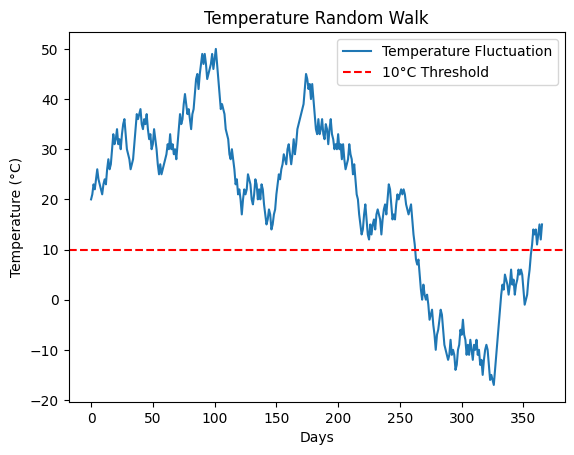

In [14]:
#     **Solution**
# Type your solution here.

import matplotlib.pyplot as plt

# a. Generate a random walk of 365 steps
np.random.seed(42)
steps = np.random.choice([-3, -2, -1, 1, 2, 3], size=365)
temperatures = np.cumsum(np.insert(steps, 0, 20))

# b. Maximum deviation from starting temperature
max_deviation = np.max(np.abs(temperatures - 20))
print("Max Deviation:", max_deviation)

# c. Count times temperature dropped below 10°C
below_10_count = np.sum(temperatures < 10)
print("Days below 10°C:", below_10_count)

# d. Plot temperature fluctuation over time
plt.plot(temperatures, label="Temperature Fluctuation")
plt.axhline(10, color='r', linestyle='--', label="10°C Threshold")
plt.xlabel("Days")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Random Walk")
plt.legend()
plt.show()

# e. Modify step distribution with normal distribution
rng = np.random.default_rng(42)
steps_normal = rng.standard_normal(365) * 2  # Mean=0, StdDev=2
temperatures_normal = np.cumsum(np.insert(steps_normal, 0, 20))


### Q6  
Given a 2D NumPy array of temperature readings from 5 cities over 10 days: 
 
```python
temps_2d = np.random.randint(10, 40, size=(5, 10))  
```  
- a. Find the **city with the highest average temperature**.  
- b. Find the **day with the lowest recorded temperature**.  
- c. Replace any temperature above **35°C** with the **average of its row**.  


In [18]:
#     **Solution**
# Type your solution here.

temps_2d = np.random.randint(10, 40, size=(5, 10))
print("Temperature Data:\n", temps_2d, "\n")

# a. Find city with the highest average temperature
city_avg_temps = np.mean(temps_2d, axis=1)
city_highest_avg = np.argmax(city_avg_temps)
print("City with highest average temperature:", city_highest_avg, "\n")

# b. Find day with the lowest recorded temperature
day_lowest_temp = np.argmin(np.min(temps_2d, axis=0))
print("Day with lowest recorded temperature:", day_lowest_temp, "\n")

# c. Replace temperatures above 35°C with row average
# Compute row-wise mean
row_means = np.mean(temps_2d, axis=1)

# Find positions where temperatures exceed 35°C
mask = temps_2d > 35

# Replace values > 35°C with their respective row mean
for i in range(temps_2d.shape[0]):  # Iterate over rows
    temps_2d[i, mask[i]] = row_means[i]  # Assign row mean to matching elements

print("Modified Temperature Data:\n", temps_2d)


Temperature Data:
 [[14 31 34 38 23 37 14 24 26 39]
 [23 39 29 14 21 25 35 35 25 30]
 [16 13 10 39 39 14 32 35 19 31]
 [14 13 11 29 19 35 28 35 10 33]
 [14 22 13 25 33 25 32 11 26 37]] 

City with highest average temperature: 0 

Day with lowest recorded temperature: 2 

Modified Temperature Data:
 [[14 31 34 28 23 28 14 24 26 28]
 [23 27 29 14 21 25 35 35 25 30]
 [16 13 10 24 24 14 32 35 19 31]
 [14 13 11 29 19 35 28 35 10 33]
 [14 22 13 25 33 25 32 11 26 23]]
